centrality
- Degree
- Betweenness
- Pagerank
- CI

In [2]:
'''centrality '''
from copy import deepcopy
from typing import Callable
import igraph as ig
import random
from utils.heuristics import Degree,Betweenness,PageRank,CollectiveInfluence

def CentralityAdaptive(g:ig.Graph,heuristic:Callable,step_ratio=None,max_iterations=None,**kwargs):
    '''
    heuristic: optional[Degree,Betweenness,PageRank,CollectiveInfluence]
    return the heuristic based node list using static_id attribute to track original IDs
    '''
    if step_ratio == None: 
        step_ratio = 1/g.vcount()
    if max_iterations is None:
        max_iterations = 1/step_ratio

    g_copy = deepcopy(g)    
    # Add static_id attribute to track original node IDs
    g_copy.vs['static_id'] = list(range(g.vcount()))
    iteration = 0
    result = []

    while g_copy.vcount() > 0 and g_copy.ecount() > 0 and iteration < max_iterations:
        # calculate how many nodes to remove
        k = max(1, int(g_copy.vcount() * step_ratio))
        
        # get top k nodes from current graph
        cur_node_list = heuristic(g_copy, k, **kwargs)
        
        # map back to original node IDs using static_id attribute
        original_node_ids = [g_copy.vs[node]['static_id'] for node in cur_node_list]
        result.extend(original_node_ids)
        
        # remove nodes from graph copy (static_id is automatically maintained for remaining nodes)
        g_copy.delete_vertices(cur_node_list)
        iteration += 1
    return result


# Test the heuristic functions
print("Testing heuristic methods...")
g_test = ig.Graph([(0,1),(0,2),(0,3),(1,3),(2,4),(3,4)])
print(f"Test graph: {g_test.vcount()} nodes, {g_test.ecount()} edges")
print(f"Degrees: {g_test.degree()}")

random.seed(0)
g_test = ig.Graph.Erdos_Renyi(n=10, p=0.2)
print(f"Test graph: {g_test.vcount()} nodes, {g_test.ecount()} edges")
print("\nTesting CentralityAdaptive with different methods...")
print(f"Adaptive Degree centrality result: {CentralityAdaptive(g_test, Degree, step_ratio=0.3)}")
print(f"Adaptive Betweenness centrality result: {CentralityAdaptive(g_test, Betweenness, step_ratio=0.3)}")
print(f"Adaptive PageRank centrality result: {CentralityAdaptive(g_test, PageRank, step_ratio=0.3)}")
print(f"Adaptive CI centrality result: {CentralityAdaptive(g_test, CollectiveInfluence, step_ratio=0.3,radius = 3)}")


Testing heuristic methods...
Test graph: 5 nodes, 6 edges
Degrees: [3, 2, 2, 3, 2]
Test graph: 10 nodes, 8 edges

Testing CentralityAdaptive with different methods...
Adaptive Degree centrality result: [7, 8, 2]
Adaptive Betweenness centrality result: [7, 8, 2]
Adaptive PageRank centrality result: [7, 2, 8]
Adaptive CI centrality result: [0, 1, 2, 3, 4, 5, 6]


## MultiStage dismantling

### Stage 1: Preprocess


### Stage 2: Dismantling

In [11]:
import igraph as ig
from copy import deepcopy
from typing import Callable,Dict
import numpy as np
import utils
import importlib
importlib.reload(utils)
from baseline import ensure_static_id
  
def dismantling(g:ig.Graph,dismantling_method,ckpt_pth=None,**kwargs):
    '''
    same return with preprocess
    removals: complete solution
    removed_sizes: cumulative removed number at each step, start from 0
    lcc_sizes: lcc size at each step, len(lcc_sizes) = len(removed_sizes)
    '''
    g = deepcopy(g)
    ensure_static_id(g)

    # Implementation
    if dismantling_method is None:
        dismantling_method = CentralityAdaptive
        #TODO defalut kwargs


    # If using CentralityAdaptive, pass the centrality and step_ratio
    if dismantling_method == CentralityAdaptive:
        result = dismantling_method(g, **kwargs)

    # elif dismantling_method == FINDER:
    #     result = dismantling_method(g, **kwargs)
        
    elif dismantling_method == 'MIND':
        from networks.dismantle import SACPolicy
        import torch
        from utils.validate import validate_one_graph
        device: str='cuda:0'
        # device = torch.device('cpu')
        sac = SACPolicy(
            num_features=16,
            num_heads=4,
            num_mps=6,
        ).to(device)
        # sac.load_state_dict(torch.load(args.ckpt_pth, weights_only=True)['policy_state_dict'])
        sac.load_state_dict(torch.load(ckpt_pth)['policy_state_dict'])
        auc, robustness, _, removals = validate_one_graph(g,policy=sac,log_removals=True, **kwargs)
        # print(auc, robustness,removals)

    
    #map static id to result if static_id is provided
    for i,node_id in enumerate(removals):
        # Use static_id to get the true original node ID
        if 'static_id' in g.vs.attributes():
            original_node_id = g.vs[node_id]['static_id']
        else:
            original_node_id = node_id
        removals[i] = original_node_id
    
    return auc, robustness, removals


from utils.common import load_g
G = load_g("graphs/test/simple_100.pkl",name="test")
test_auc, test_robustness, test_removals = dismantling(
    G,
    'MIND',
    ckpt_pth = 'saved/mind.ckpt',
    step_ratio = 0
)


import baseline
import importlib
importlib.reload(baseline)
from baseline import evaluate_sol
test_auc, test_robustness = evaluate_sol(G,test_removals)
print(test_auc,test_robustness)



Graph: test, AUC=46.923333, Robustness=0.464500, Steps=85
46.92333333333333 0.4645


#### compare dismantling models

Graph: test, AUC=90.670194, Robustness=0.477310, Steps=161
Graph: test, AUC=90.978836, Robustness=0.478990, Steps=162
Graph: test, AUC=90.931217, Robustness=0.478738, Steps=162
Graph: test, AUC=90.026455, Robustness=0.473951, Steps=160
Graph: test, AUC=90.693122, Robustness=0.477478, Steps=162
method Spectral: AUC=86.56261022927687, Robustness=0.4555023655552756
method Degree: AUC=92.53439153439152, Robustness=0.4869124604574339
method Betweenness: AUC=87.09523809523807, Robustness=0.45802189188432585
method CI: AUC=88.85008818342149, Robustness=0.4675401024607374


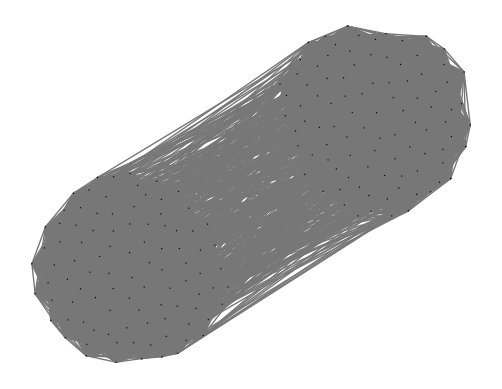

<Figure size 600x400 with 0 Axes>

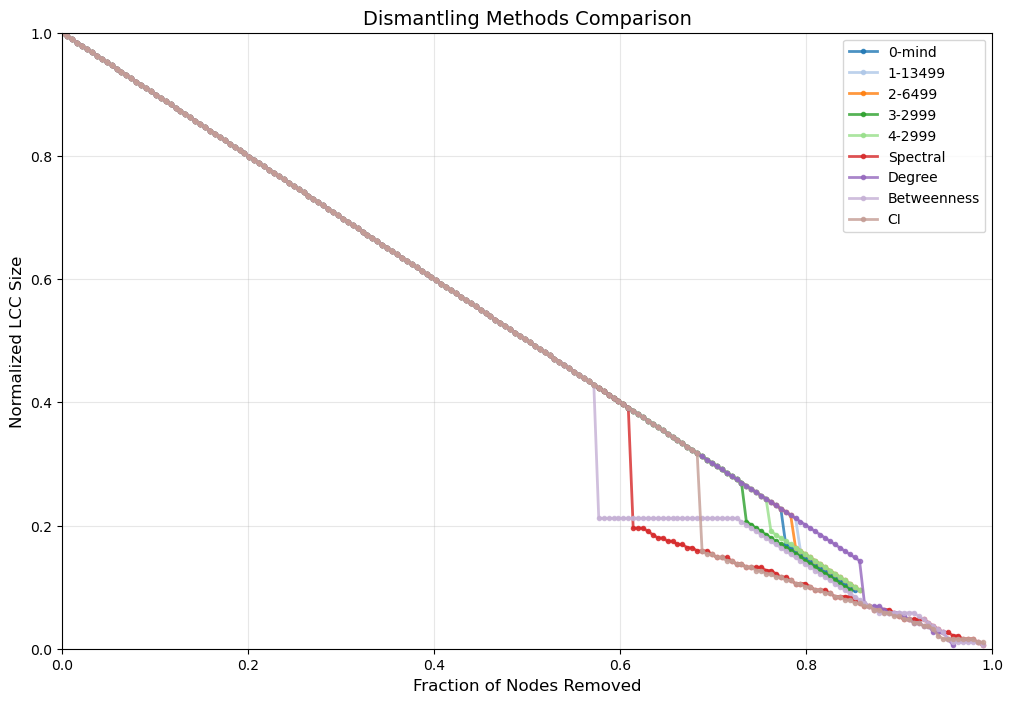

In [7]:
import matplotlib.pyplot as plt
import os
import importlib
import utils
import visualize_dismantling
import baseline
importlib.reload(utils)
importlib.reload(visualize_dismantling)
importlib.reload(baseline)
from utils.common import load_g
from utils.plot import plot_graph

g_name = 'test'
# g = load_g(f'graphs/real/FINDER/Crime.pkl',name=g_name)
# g = load_g(f'graphs/real/bio/maayan-figeys.pkl',name=g_name)
# g = load_g(f'graphs/real/tech/gridkit-north_america.pkl',name=g_name)
# g = load_g(f'graphs/train/100_200_RGG_2000/00008.pkl',name=g_name)
g = load_g(f'graphs/train/100_200_SBM_2000/00010.pkl',name=g_name)
# g = ig.Graph.GRG(n=500, radius=0.13)

plot_graph(g)

all_results = {}
compare_models = [
                    'saved/mind.ckpt',
                    # 'saved/finetune_20251216_003004/7999.ckpt',
                    # 'saved/finetune_20251216_140104/2999.ckpt',
                    # 'saved/finetune_20251216_180547/9999.ckpt',
                    # 'saved/finetune_20251216_180547/7999.ckpt',
                    # 'saved/finetune_20251217_145647/5999.ckpt',
                    'saved/finetune_20251218_185945/13499.ckpt', #100-200,RGG
                    'saved/finetune_20251222_000136/6499.ckpt',  #100-200,SBM
                    'saved/finetune_20251222_210303/2999.ckpt',  #100-200,SBM,spectral
                    'saved/finetune_20251223_141913/2999.ckpt'   #100-200,SBM,betweenness   
                    ]

for idx, ckpt_pth in enumerate(compare_models):
    _, _, test_removals  = dismantling(g,'MIND',step_ratio=0.0,ckpt_pth=ckpt_pth)
    method_name = str(idx)+ '-' + os.path.basename(ckpt_pth).replace('.ckpt', '')
    all_results[method_name] = test_removals

from baseline import baseline_dismantling,METHODS
methods = {
    "Spectral":METHODS['Spectral'],
    "Degree":METHODS['Degree'],
    "Betweenness":METHODS['Betweenness'],
    "CI": METHODS['CI'],
}
baseline_results = baseline_dismantling(g,methods,visualize=False)
all_results.update(baseline_results)

from visualize_dismantling import visualize_multiple_curve
visualize_multiple_curve(g,all_results)

Graph: test, AUC=53.605556, Robustness=0.442917, Steps=97
Graph: test, AUC=53.594444, Robustness=0.442639, Steps=97
Graph: test, AUC=53.594444, Robustness=0.442639, Steps=97
Graph: test, AUC=53.802778, Robustness=0.444583, Steps=99
Graph: test, AUC=54.208333, Robustness=0.447986, Steps=100
method Spectral: AUC=52.2875, Robustness=0.4316666666666667
method Degree: AUC=57.37222222222222, Robustness=0.4740972222222222
method Betweenness: AUC=52.15833333333333, Robustness=0.43055555555555564
method CI: AUC=54.80833333333332, Robustness=0.4526388888888889


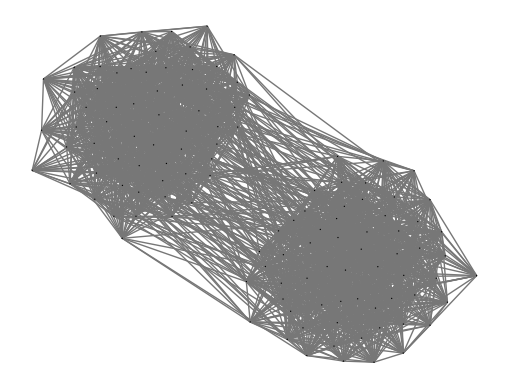

<Figure size 600x400 with 0 Axes>

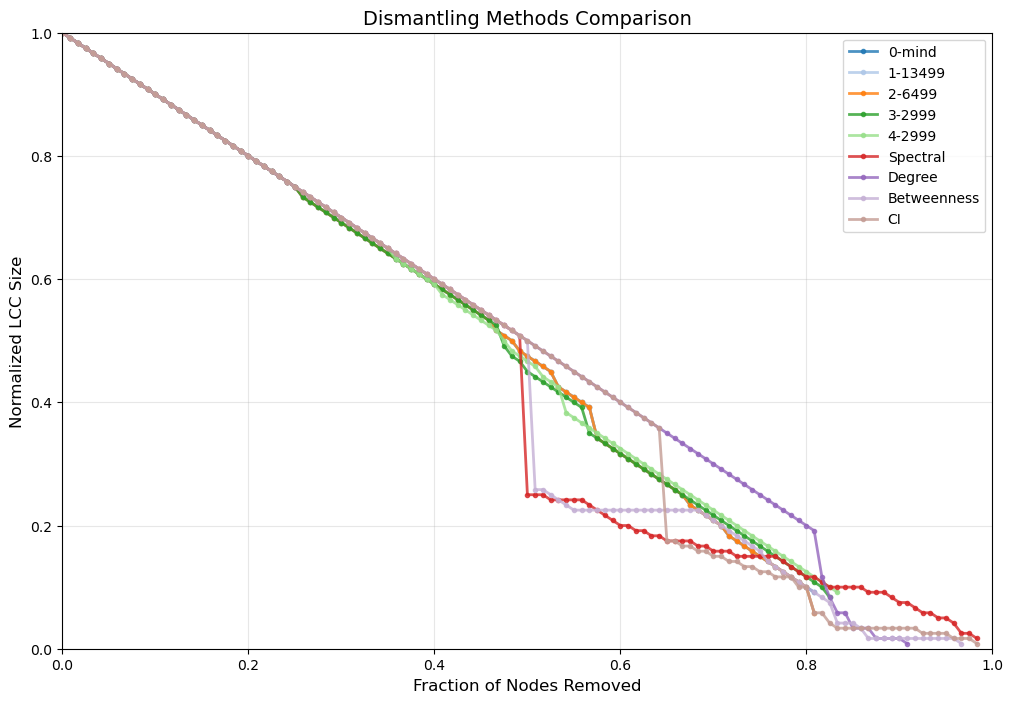

In [ ]:
import matplotlib.pyplot as plt
import importlib
import utils
import visualize_dismantling
import baseline
importlib.reload(utils)
importlib.reload(visualize_dismantling)
importlib.reload(baseline)
from utils.common import load_g
from utils.plot import plot_graph
from visualize_dismantling import visualize_multiple_dynamic
from graphs.graph_models import stochastic_block_model

p_in = 0.5
p_out = 0.05
g = stochastic_block_model(120,p_in,p_out,2)
g['name'] = 'test' 

plot_graph(g)
all_results = {}
compare_models = [
                    'saved/mind.ckpt',
                    # 'saved/finetune_20251216_003004/7999.ckpt',
                    # 'saved/finetune_20251216_140104/2999.ckpt',
                    # 'saved/finetune_20251216_180547/9999.ckpt',
                    # 'saved/finetune_20251216_180547/7999.ckpt',
                    # 'saved/finetune_20251217_145647/5999.ckpt',
                    'saved/finetune_20251218_185945/13499.ckpt', #100-200,RGG
                    'saved/finetune_20251222_000136/6499.ckpt',  #100-200,SBM
                    'saved/finetune_20251222_210303/2999.ckpt',  #100-200,SBM,spectral
                    'saved/finetune_20251223_141913/2999.ckpt'   #100-200,SBM,betweenness   
                    ]

for idx, ckpt_pth in enumerate(compare_models):
    _, _, test_removals  = dismantling(g,'MIND',step_ratio=0.0,ckpt_pth=ckpt_pth)
    method_name = str(idx) + '-'+ os.path.basename(ckpt_pth).replace('.ckpt', '')
    all_results[method_name] = test_removals

from baseline import baseline_dismantling,METHODS
methods = {
    "Spectral":METHODS['Spectral'],
    "Degree":METHODS['Degree'],
    "Betweenness":METHODS['Betweenness'],
    "CI": METHODS['CI'],
}
baseline_results = baseline_dismantling(g,methods,visualize=False)
all_results.update(baseline_results)

from visualize_dismantling import visualize_multiple_curve
visualize_multiple_curve(g,all_results)

# visualize_multiple_dynamic(g,all_results,output_dir="temp")


# baselines

  Running CoreHD...
method CoreHD dismantling time:  0.012998342514038086
method CoreHD: AUC=96.8725, Robustness=0.48217499999999996
  Running Spectral...
method Spectral dismantling time:  2.88761043548584
method Spectral: AUC=97.45458333333335, Robustness=0.4847999999999999
  Running SpectralA...
method SpectralA dismantling time:  31.648996829986572
method SpectralA: AUC=96.74749999999999, Robustness=0.4812749999999999


AttributeError: 'NoneType' object has no attribute 'seek'. You can only torch.load from a file that is seekable. Please pre-load the data into a buffer like io.BytesIO and try to load from it instead.

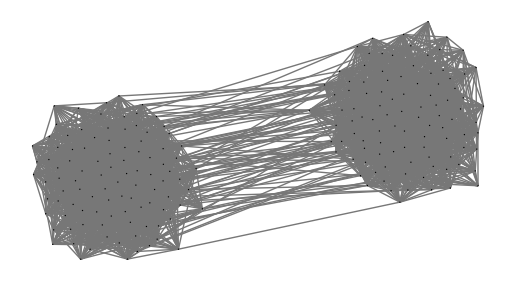

<Figure size 600x400 with 0 Axes>

In [ ]:
import igraph as ig
import importlib
import baseline
importlib.reload(baseline)
from utils.plot import plot_graph
from baseline import baseline_dismantling,METHODS

pref_matrix = [[0.3, 0.01], [0.01, 0.3]]
G_sbm = ig.Graph.SBM(n=200, pref_matrix=pref_matrix, block_sizes=[100, 100])
G_sbm.vs['static_id'] = list(range(100)) # Keep track of original IDs
plot_graph(G_sbm)

methods = {
    "CoreHD": METHODS['CoreHD'],
    "Spectral":METHODS['Spectral'],
    "SpectralA":METHODS['SpectralA'],
}

baseline_results = baseline_dismantling(G_sbm,methods,visualize=False)

# Compare with MIND
auc, robustness, removals = dismantling(
    G_sbm,
    'MIND',
    step_ratio = 0,
    ckpt_pth = 'saved/mind.ckpt'
)

all_results = baseline_results
all_results['MIND'] = removals

from visualize_dismantling import visualize_multiple_curve
visualize_multiple_curve(G_sbm,all_results)



  Running CoreHD...
method CoreHD dismantling time:  0.0019404888153076172
  Running Spectral...
method Spectral dismantling time:  0.13901114463806152
  Running SpectralA...
method SpectralA dismantling time:  6.9708757400512695


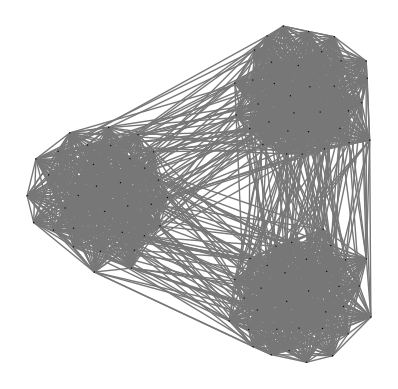

<Figure size 600x400 with 0 Axes>

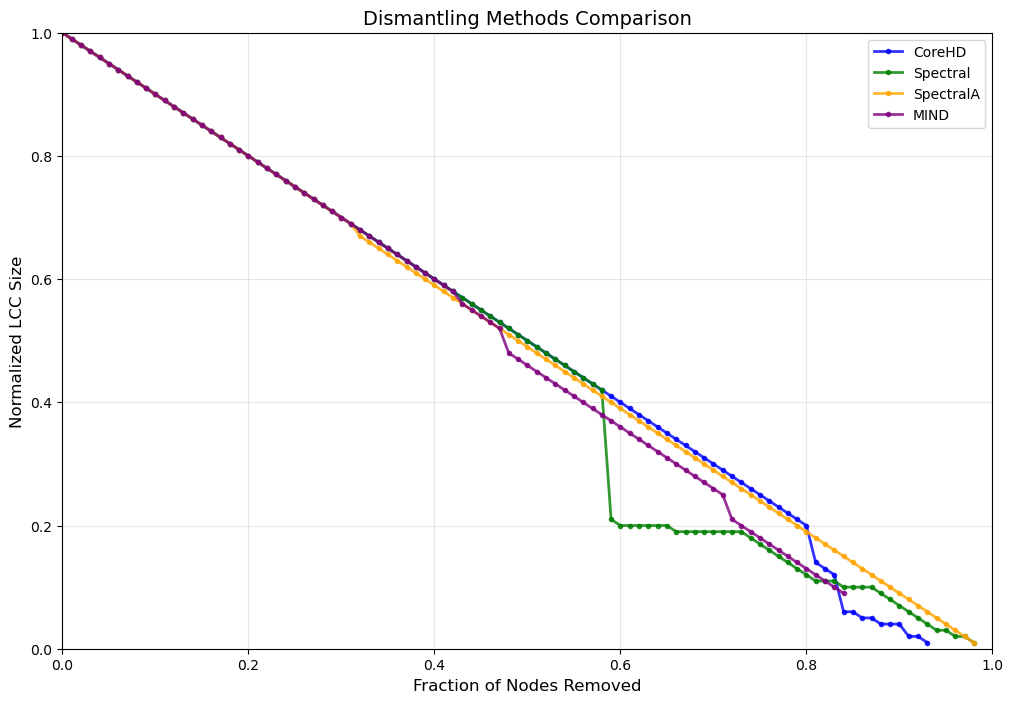

In [ ]:
import importlib
import graphs
importlib.reload(graphs)
# from graph_analysis import statistics
from graphs.graph_models import stochastic_block_model
G_sbm = stochastic_block_model(N=100)
G_sbm.vs['static_id'] = list(range(100)) # Keep track of original IDs
plot_graph(G_sbm)
# statistics(G_sbm)
baseline_results = baseline_dismantling(G_sbm,methods,visualize=False)

# Compare with MIND
auc, robustness, removals, removed_sizes, lcc_sizes = dismantling(
    G_sbm,
    MIND,
    step_ratio = 0
)

all_results = baseline_results
all_results['MIND'] = removals

from visualize_dismantling import visualize_multiple_curve
visualize_multiple_curve(G_sbm,all_results)

In [81]:
np.random.rand()

0.7829169232207657

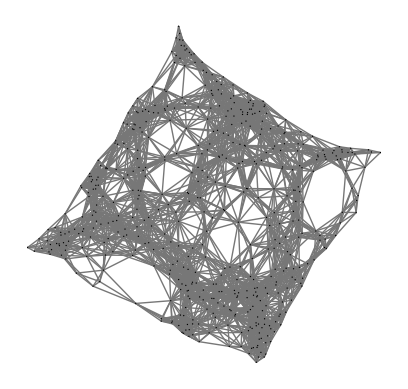

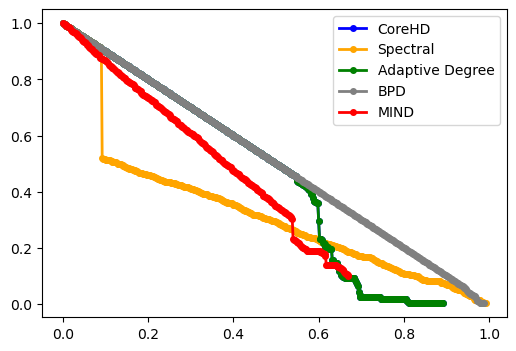

{}

In [53]:
# Setup SBM
# Generate a 2D Random Geometric Graph
# n=500 nodes, radius=0.12 (threshold for connectivity)
G_rgg = ig.Graph.GRG(n=500, radius=0.12)
G_rgg.vs['static_id'] =list(range(G_rgg.vcount())) 
plot_graph(G_rgg)
benchmark_dismantling(G_rgg, methods)

method CoreHD dismantling time:  0.0009982585906982422
method Spectral dismantling time:  0.6260161399841309
method Adaptive Degree dismantling time:  0.0010013580322265625
method BPD dismantling time:  0.09661102294921875


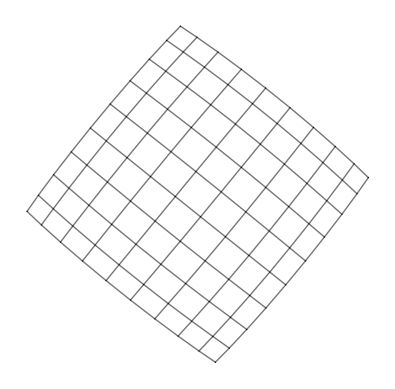

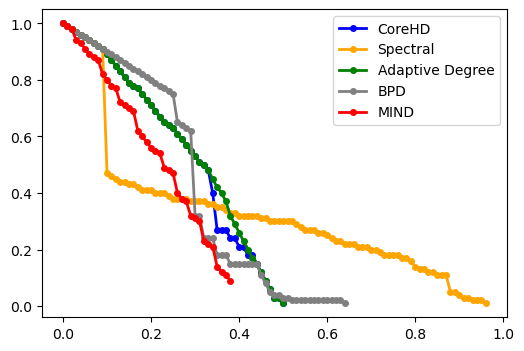

In [65]:

G_grid = ig.Graph.Lattice([10, 10], circular=False)
# Run on a Grid or SBM
G_grid.vs['static_id'] = list(range(G_grid.vcount()))
plot_graph(G_grid)
data = benchmark_dismantling(G_grid, methods)
